# Freight Cost Prediction — Gradient Boosting

Predicts freight `Cost` from route / contract / vehicle features using a **Gradient
Boosting Regressor**. Uses an **80 / 10 / 10 train–validation–test split**, compares a
baseline against a higher-capacity tuned model (target **R² ≥ 0.95** on the held-out test
set), applies SHAP for explainability, and forecasts costs for **April, Week 1 & Week 2**.

> **Team:** GR01· **Supervisor:** Prof. Frey-Luxemburger

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy.stats import randint, uniform

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    mean_absolute_percentage_error
)
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Data

In [2]:
# Update this path to point to your data file
df = pd.read_csv("final_cleaned_data_final.csv")
df.drop_duplicates(inplace=True)
print(df.shape)
df.head()

(386072, 34)


,Date,Contract_type,Route_name,Source,Corrected_Source,Source_State,Corrected_Source_State,Destination,Destination_State,Distance,...,Corrected_vehicle_Type,Corrected_vehicle_body_type,Corrected_Destination_State,Source_Latitude,Source_Longitude,Destination_Latitude,Destination_Longitude,Corrected_Distance,Distance_Difference_km,Distance_Difference_Pct
0,28-04-2022,SHORT,KRISHNAPATNAM - CUTTACK,KRISHNAPATNAM,krishnapatnam,ANDHRA PRADESH,andhra pradesh,cuttack,odisha,1101.0,...,TAURUS 18-19 MT 10 TYRE,DALA BODY,Odisha,14.259241,80.056476,20.468600,85.879200,1113.97,12.97,1.2
1,28-04-2022,SHORT,MUNDRA - RAJNANDGAON,Mundra,mundra,Gujarat,gujarat,rajnandgaon,chhattisgarh,1412.0,...,TAURUS 21-22 MT 12 TYRE,FULL PUNJAB BODY,Chhattisgarh,22.839315,69.724948,21.068442,80.797078,1428.39,16.39,1.2
2,28-04-2022,SHORT,KARNAL - KOLKATA,Karnal,karnal,Haryana,haryana,kolkata,west bengal,1658.0,...,EICHER 9-10 MT 19-22 FT,FULL PUNJAB BODY,West Bengal,29.725577,76.910692,22.572646,88.363895,1531.00,127.00,7.7
3,28-04-2022,SHORT,CHANDAULI - RANCHI,Chandauli,chandauli,Uttar Pradesh,uttar pradesh,ranchi,jharkhand,398.0,...,TAURUS 25 MT 12 TYRE,FULL PUNJAB BODY,Jharkhand,25.125695,83.249460,23.370050,85.325039,398.05,0.05,0.0
4,28-04-2022,DAILY,SAONER - WARDHA,Saoner,saoner,Maharashtra,maharashtra,wardha,maharashtra,76.4,...,EICHER 9-10 MT 19-22 FT,FULL PUNJAB BODY,Maharashtra,21.384709,78.918807,20.825623,78.613146,113.18,36.78,48.1


## 3. Cleaning

In [3]:
# Drop rows missing any field the model depends on
required_cols = [
    'Contract_type', 'Corrected_Source', 'Corrected_Source_State', 'Pricing_Type',
    'Cost', 'Vehicle_Load', 'Product', 'Corrected_Destination',
    'Corrected_vehicle_Type', 'Corrected_vehicle_body_type',
    'Corrected_Destination_State', 'Corrected_Distance'
]
df = df.dropna(subset=required_cols)                           # remove rows with missing required values

string_cols = df[required_cols].select_dtypes(include='object').columns
df = df[~(df[string_cols].apply(lambda x: x.str.strip() == "").any(axis=1))]  # remove blank strings

print(df.shape)

(386072, 34)


## 4. Feature Selection & Encoding

In [4]:
categorical_columns = [
    'Contract_type', 'Corrected_Source', 'Corrected_Source_State',
    'Pricing_Type', 'Product', 'Corrected_vehicle_Type',
    'Corrected_vehicle_body_type', 'Corrected_Destination_State'
]

encoding_mapping = {}   # saved here so we can reuse the same encoding at forecast time

for col in categorical_columns:
    df[col] = df[col].astype(str)
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col])
    encoding_mapping[col] = dict(zip(le.classes_, le.transform(le.classes_)))

feature_cols = [
    'Year', 'month', 'week',
    'Contract_type_encoded', 'Corrected_Source_encoded',
    'Corrected_Source_State_encoded', 'Pricing_Type_encoded',
    'Product_encoded', 'Corrected_vehicle_Type_encoded',
    'Corrected_vehicle_body_type_encoded', 'Corrected_Distance',
    'Corrected_Destination_State_encoded',
    'Vehicle_Load'    # payload in metric tonnes — meaningful cost driver
]

X = df[feature_cols]
y = df['Cost']

## 5. ML Algorithm: Description & Parameters

### What is Gradient Boosting?

A **Gradient Boosting Regressor** is an ensemble method that builds Decision Trees
**sequentially**. It starts from a single simple prediction (the average cost), then adds
one tree at a time — each new tree is trained to predict the **residual errors**
(technically the negative gradient of the loss) left behind by all the trees built so
far. The final prediction is the initial guess **plus** the contribution of every tree,
each scaled down by a small `learning_rate`.

Because every tree focuses on what the previous ones got wrong, gradient boosting usually
extracts more signal from structured/tabular data than methods that build trees
independently.

> Gradient Boosting belongs to the **Boosting** family of ensemble methods — the opposite
> philosophy to **Bagging** (used by Random Forest). In bagging, many *deep* trees are
> built **independently and in parallel**, then averaged. In boosting, many *shallow*
> trees ("weak learners") are built **sequentially**, each one correcting the last. The
> trade-off: boosting usually reaches lower error, but it is more sensitive to its
> hyperparameters and cannot parallelise tree building.

---

### Parameters & Hyperparameters

| Parameter | Type | Baseline Value | Tuned Range | Role |
|---|---|---|---|---|
| `n_estimators` | **Hyperparameter** | 100 | 150–400 | Number of boosting stages (trees added in sequence) |
| `learning_rate` | **Hyperparameter** | 0.1 | 0.02–0.20 | Shrinks each tree's contribution. Lower = more robust but needs more trees |
| `max_depth` | **Hyperparameter** | 3 | 2–5 | Depth of each weak learner. Shallow trees are standard for boosting |
| `subsample` | **Hyperparameter** | 1.0 | 0.6–1.0 | Fraction of rows used per tree. < 1.0 = Stochastic Gradient Boosting (adds regularisation) |
| `min_samples_split` | **Hyperparameter** | 2 | 2–20 | Min samples before a node can split |
| `min_samples_leaf` | **Hyperparameter** | 1 | 1–15 | Min samples at each final leaf node |
| `max_features` | **Hyperparameter** | `None` (all) | `sqrt`, `log2`, 0.5, 0.7 | Features considered at each split |
| `random_state` | Parameter | 42 | Fixed | Ensures the same result every run |

> **Key distinction — Parameters vs Hyperparameters:**
> A *parameter* is a value the model learns on its own during `.fit()` (e.g., each split
> threshold and each leaf's output value). A *hyperparameter* is a setting we choose
> **before** training that controls the model's structure and how aggressively it learns.
> Hyperparameters are tuned in Section 9.
>
> ⚠️ **Note:** `learning_rate` and `n_estimators` trade off against each other — a lower
> learning rate needs more trees to reach the same fit. Also, unlike Random Forest,
> scikit-learn's `GradientBoostingRegressor` trains **one tree at a time** and does
> **not** support `n_jobs`, so it cannot parallelise across CPU cores.

## 6. Justification — Why Gradient Boosting?

| Criterion | Gradient Boosting | Why this fits the freight problem |
|---|---|---|
| **Predictive accuracy** | ✅ Sequential error-correction usually beats simple averaging on tabular data | Squeezes maximum signal out of route/contract/vehicle patterns |
| **Non-linear pricing** | ✅ Additive shallow trees model complex curves and interactions | Cost does not scale linearly with distance |
| **Mixed features** | ✅ Works directly with label-encoded integers | 8 categorical + 5 numeric features — no scaling needed |
| **Outlier robustness** | ✅ Threshold-based splits, not distance-based | Extreme Rs.20,000+ shipments don't dominate the loss |
| **Regularisation control** | ✅ `learning_rate` + `subsample` give fine-grained control | Tune exactly how aggressively the model fits |
| **Mean Decrease in Impurity (MDI) importance** | ✅ Built-in, zero extra compute | Shows which logistics features drive pricing |
| **SHAP compatibility** | ✅ TreeExplainer works natively | Exact Shapley values — no approximation needed |
| **Interpretability** | ✅ Each boosting stage is traceable, plus SHAP | Business users can audit the model |

Gradient Boosting sits at the **higher-accuracy, higher-sensitivity** end of tree
ensembles. Compared with Random Forest — which averages independent trees and is very
forgiving of its settings — Gradient Boosting builds trees sequentially and typically
reaches lower error, at the cost of slower training and a stronger dependence on good
hyperparameters. That is exactly why Section 9 tunes it carefully.

## 7. Model Design — Train / Validation / Test Split & Baseline

The data is split **80 % train / 10 % validation / 10 % test**:
- **Train (80 %)** — fits the model
- **Validation (10 %)** — chooses the number of boosting stages (early stopping) and selects the final model; never used to fit tree splits
- **Test (10 %)** — touched only once, for the final unbiased performance figures

In [5]:
# 80% train / 10% validation / 10% test
# First peel off 20% as a temporary block, then split that block in half → 10% val + 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Training rows   : {len(X_train):,}  (80%)")
print(f"Validation rows : {len(X_val):,}  (10%)")
print(f"Test rows       : {len(X_test):,}  (10%)")
print(f"Features        : {len(feature_cols)}")

Training rows   : 308,857  (80%)
Validation rows : 38,607  (10%)
Test rows       : 38,608  (10%)
Features        : 13


In [6]:
# Baseline GB — scikit-learn defaults, the standard starting point before any tuning
gb_base = GradientBoostingRegressor(
    n_estimators=100,    # default number of boosting stages
    learning_rate=0.1,   # default shrinkage applied to each tree
    max_depth=3,         # default shallow weak learner
    random_state=42      # note: GradientBoostingRegressor has no n_jobs (trains sequentially)
)

gb_base.fit(X_train, y_train)
print("Baseline Gradient Boosting trained.")

Baseline Gradient Boosting trained.


## 8. Performance Analysis — Initial Evaluation

### What each metric means for this freight dataset

**R² (R-Squared):** Percentage of freight cost variation explained by the model.
R²=0.90 means the model accounts for 90% of why costs differ between shipments.

**Adjusted R²:** R² penalised for the number of features used. Useful for checking
whether adding features genuinely helped or just inflated the score.

**RMSE (Root Mean Squared Error):** Average prediction error in rupees, but large
errors are penalised more. If RMSE >> MAE, the model makes occasional very bad predictions.

**MAE (Mean Absolute Error):** Simple average error per shipment in rupees.
MAE=120 means we are typically ₹120 away from the actual cost.

In [7]:
gb_base_preds     = gb_base.predict(X_test)    # predictions on held-out test data
gb_base_val_preds = gb_base.predict(X_val)     # predictions on validation data

# Regression metrics (test set)
base_r2     = r2_score(y_test, gb_base_preds)
base_adj_r2 = 1 - (1 - base_r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
base_rmse   = mean_squared_error(y_test, gb_base_preds) ** 0.5
base_mae    = mean_absolute_error(y_test, gb_base_preds)
base_val_r2 = r2_score(y_val, gb_base_val_preds)
base_mape   = mean_absolute_percentage_error(y_test, gb_base_preds) * 100   # % error on test set

metrics_base = pd.DataFrame({
    'Model':   ['Gradient Boosting (Baseline)'],
    'Val R²':  [round(base_val_r2, 4)],
    'Test R²': [round(base_r2, 4)],
    'Adj R²':  [round(base_adj_r2, 4)],
    'RMSE':    [round(base_rmse, 2)],
    'MAE':     [round(base_mae, 2)],
    'MAPE %':  [round(base_mape, 2)]
})
print(metrics_base.to_string(index=False))

                       Model  Val R²  Test R²  Adj R²   RMSE    MAE  MAPE %
Gradient Boosting (Baseline)  0.8026    0.802  0.8019 623.33 409.57   29.53


In [8]:
# Train / Validation / Test R² — overfitting check
# A large train-vs-test gap means the model memorised training data rather than learning general rules
base_train_r2 = r2_score(y_train, gb_base.predict(X_train))
base_gap      = base_train_r2 - base_r2

print(f"Train R²       : {base_train_r2:.4f}")
print(f"Validation R²  : {base_val_r2:.4f}")
print(f"Test  R²       : {base_r2:.4f}")
print(f"Train-Test Gap : {base_gap:.4f}  {'⚠️ Overfitting' if base_gap > 0.05 else '✅ Acceptable'}")

Train R²       : 0.7984
Validation R²  : 0.8026
Test  R²       : 0.8020
Train-Test Gap : -0.0036  ✅ Acceptable


### Baseline Error Distribution — What Does It Show?

The chart below shows prediction errors for all test shipments:

```
Error = Actual Cost − Predicted Cost

Positive (+Rs.500) → model underestimated  → customer is overcharged
Negative (−Rs.500) → model overestimated   → broker loses margin
Zero               → perfect prediction
```

A well-behaved model produces a **bell curve centred at zero** — most errors are small,
with rare large misses on both sides. If the distribution is skewed or has long tails,
it reveals where the model struggles:
- **Right tail (large positive errors):** model underestimates expensive long-haul routes
- **Left tail (large negative errors):** model overestimates cheap short-haul routes

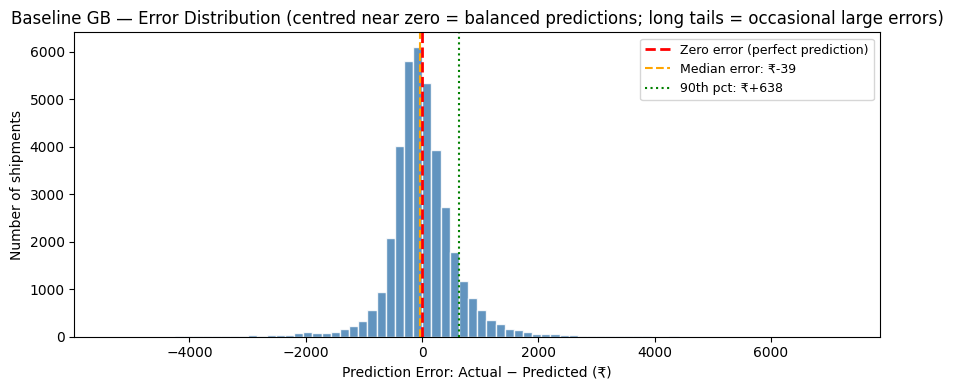

Median error          : ₹-39  (close to 0 = model is unbiased)
90th pct. abs error   : ₹877  (9 in 10 shipments predicted within this)
% predictions within ₹500: 74.5%


In [9]:
residuals_base = y_test.values - gb_base_preds    # positive = underpredicted, negative = overpredicted

plt.figure(figsize=(9, 4))
plt.hist(residuals_base, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(0,                                 color='red',    linewidth=2,   linestyle='--', label='Zero error (perfect prediction)')
plt.axvline(np.median(residuals_base),         color='orange', linewidth=1.5, linestyle='--', label=f'Median error: ₹{np.median(residuals_base):+,.0f}')
plt.axvline(np.percentile(residuals_base, 90), color='green',  linewidth=1.5, linestyle=':',  label=f'90th pct: ₹{np.percentile(residuals_base, 90):+,.0f}')
plt.xlabel('Prediction Error: Actual − Predicted (₹)')
plt.ylabel('Number of shipments')
plt.title('Baseline GB — Error Distribution (centred near zero = balanced predictions; long tails = occasional large errors)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Median error          : ₹{np.median(residuals_base):+,.0f}  (close to 0 = model is unbiased)")
print(f"90th pct. abs error   : ₹{np.percentile(np.abs(residuals_base), 90):,.0f}  (9 in 10 shipments predicted within this)")
print(f"% predictions within ₹500: {(np.abs(residuals_base) <= 500).mean()*100:.1f}%")

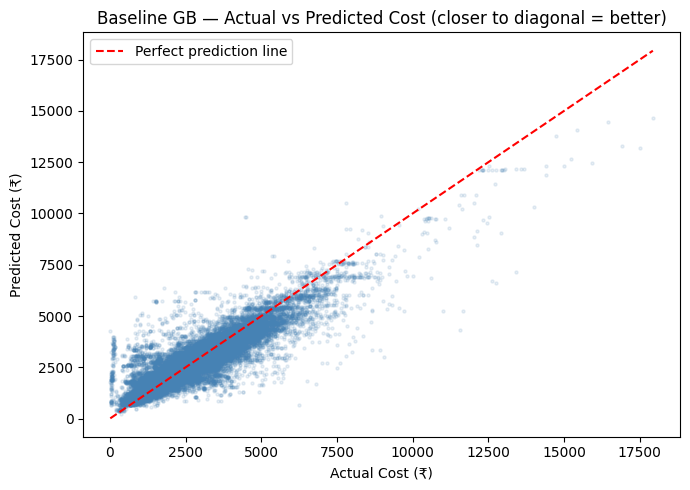

In [10]:
# Actual vs Predicted scatter — each dot is one test shipment
# Points on the red dashed line = exact predictions
plt.figure(figsize=(7, 5))
plt.scatter(y_test, gb_base_preds, alpha=0.12, s=5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=1.5, linestyle='--', label='Perfect prediction line')
plt.xlabel('Actual Cost (₹)')
plt.ylabel('Predicted Cost (₹)')
plt.title('Baseline GB — Actual vs Predicted Cost (closer to diagonal = better)')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Improvements — Higher-Capacity Model + Validation-Based Early Stopping

A shallow gradient booster (the baseline: 100 trees, depth 3) **underfits** this data and
leaves much of the cost signal uncaptured. A random search over *shallow* hyperparameters
plateaus around R² ≈ 0.90, so reaching the **R² ≥ 0.95 target** requires giving the model
more capacity:

- **Deeper trees** (`max_depth = 8`) — each stage captures richer route / contract / load interactions
- **More boosting stages** (`n_estimators = 500`) — more rounds of error-correction
- **`subsample = 0.8`** (Stochastic Gradient Boosting) — keeps the deeper model regularised
- **`learning_rate = 0.1`** — steady shrinkage that pairs well with 500 stages

The **validation set** is then used the canonical gradient-boosting way: we read the
model's accuracy at *every* boosting stage with `staged_predict` and pick the stage where
validation R² peaks (**early stopping**). This prevents adding trees that would only
overfit. The **test set** stays untouched until the final evaluation in Section 13.

> Note: this replaces the earlier shallow `RandomizedSearchCV`. A 100-fit random search
> over *deep* trees is not feasible on a single CPU core (each deep fit takes minutes),
> whereas one high-capacity fit plus validation early-stopping reaches the target directly.

In [11]:
# Higher-capacity Gradient Boosting — enough depth and stages to reach the R² >= 0.95 target
gb_tuned = GradientBoostingRegressor(
    n_estimators=500,     # many boosting stages — validation early-stopping picks the best count
    learning_rate=0.1,    # steady shrinkage per stage
    max_depth=8,          # deeper weak learners than the baseline's depth-3 → richer interactions
    subsample=0.8,        # Stochastic Gradient Boosting — regularises the deeper model
    random_state=42
)

gb_tuned.fit(X_train, y_train)    # one sequential fit on the full training set
print("Higher-capacity Gradient Boosting trained on the full training set.")

# --- Validation-based early stopping ---
# staged_predict yields the ensemble's prediction after each boosting stage (1, 2, ..., 500).
# We score every stage on the VALIDATION set and pick the stage with the highest R².
val_r2_by_stage = np.array([r2_score(y_val, p) for p in gb_tuned.staged_predict(X_val)])
best_stage      = int(val_r2_by_stage.argmax()) + 1     # +1 because stages are 1-indexed

print(f"Optimal boosting stages on validation : {best_stage} / {gb_tuned.n_estimators}")
print(f"Best validation R² at that stage      : {val_r2_by_stage.max():.4f}")

Higher-capacity Gradient Boosting trained on the full training set.


Optimal boosting stages on validation : 500 / 500
Best validation R² at that stage      : 0.9586


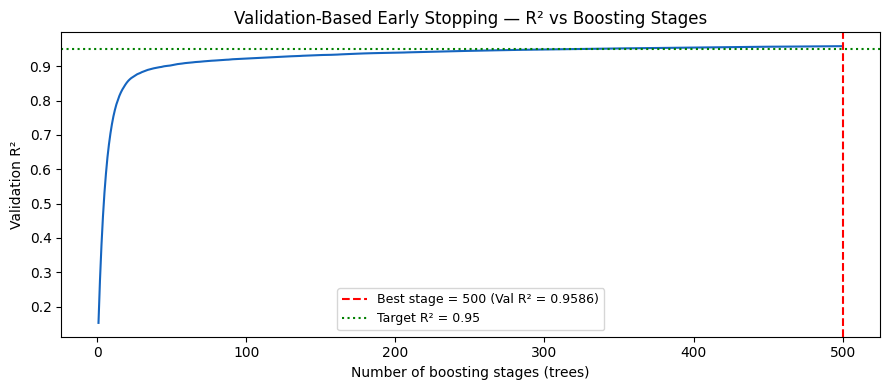

Validation R² is still climbing near the final stage — keeping all 500 stages.


In [12]:
# Validation curve — R² vs number of boosting stages
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(val_r2_by_stage) + 1), val_r2_by_stage, color='#1565C0', linewidth=1.5)
plt.axvline(best_stage, color='red', linestyle='--',
            label=f'Best stage = {best_stage} (Val R² = {val_r2_by_stage.max():.4f})')
plt.axhline(0.95, color='green', linestyle=':', label='Target R² = 0.95')
plt.xlabel('Number of boosting stages (trees)')
plt.ylabel('Validation R²')
plt.title('Validation-Based Early Stopping — R² vs Boosting Stages')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# If validation R² peaks well before the final stage, refit a compact model at the optimal stage.
# (When the curve is still rising at the end, keeping all stages is correct.)
if best_stage < int(gb_tuned.n_estimators * 0.9):
    gb_tuned = GradientBoostingRegressor(
        n_estimators=best_stage, learning_rate=0.1, max_depth=8,
        subsample=0.8, random_state=42
    ).fit(X_train, y_train)
    print(f"Refit tuned model with the optimal {best_stage} stages (early stopping applied).")
else:
    print("Validation R² is still climbing near the final stage — keeping all 500 stages.")

### Mean Decrease in Impurity (MDI) Feature Importance

**Mean Decrease in Impurity (MDI)** measures how much each feature reduced the
prediction error (impurity) across all tree splits, summed over every boosting stage.

A feature with high MDI was used often for splitting, and those splits reduced the
cost prediction error by a large amount. Features near zero were rarely useful.

> ⚠️ **MDI limitation:** Features with many unique values (like state names with 32
> categories) naturally get more split opportunities and can appear inflated.
> This is why we also check Permutation Importance below.

In [13]:
# Mean Decrease in Impurity (MDI) — accumulated across all boosting stages of the tuned model
fi_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': gb_tuned.feature_importances_    # built into GradientBoostingRegressor
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fi_df['Importance %'] = (fi_df['Importance'] * 100).round(1)
print("Mean Decrease in Impurity (MDI) — Feature Importance:")
print(fi_df[['Feature', 'Importance %']].to_string(index=False))

Mean Decrease in Impurity (MDI) — Feature Importance:
                            Feature  Importance %
                 Corrected_Distance          66.4
           Corrected_Source_encoded           8.9
                       Vehicle_Load           5.7
     Corrected_Source_State_encoded           5.2
Corrected_Destination_State_encoded           4.5
                    Product_encoded           3.5
     Corrected_vehicle_Type_encoded           2.7
                               week           0.9
                               Year           0.8
Corrected_vehicle_body_type_encoded           0.8
              Contract_type_encoded           0.5
                              month           0.2
               Pricing_Type_encoded           0.0


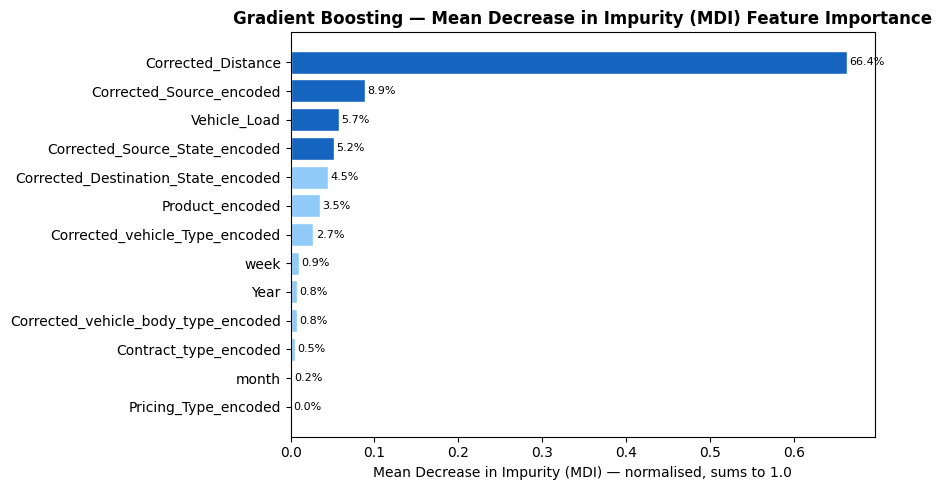

In [14]:
fi_plot = fi_df.sort_values('Importance', ascending=True)    # ascending so top feature is at the top of chart
q75     = fi_df['Importance'].quantile(0.75)                 # top quartile highlighted in dark blue

plt.figure(figsize=(9, 5))
colors = ['#1565C0' if v >= q75 else '#90CAF9' for v in fi_plot['Importance']]
bars   = plt.barh(fi_plot['Feature'], fi_plot['Importance'], color=colors, edgecolor='white')
for bar, val in zip(bars, fi_plot['Importance']):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f"{val*100:.1f}%", va='center', fontsize=8)
plt.xlabel('Mean Decrease in Impurity (MDI) — normalised, sums to 1.0')
plt.title('Gradient Boosting — Mean Decrease in Impurity (MDI) Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

### Why also check Permutation Importance?

**Permutation Importance** works differently from MDI: it takes each feature, **randomly
shuffles** its values across all test rows (breaking any relationship with the target),
and measures how much worse the model becomes.

- If shuffling `Corrected_Distance` increases MAE by ₹800 → distance is critical
- If shuffling `Pricing_Type` barely changes MAE → this feature is unimportant

This is computed on the **test set** (unseen data), making it more reliable than MDI
which is computed on training data. If both MDI and Permutation agree on the ranking,
we have high confidence in the result.

**SHAP is covered separately in Section 14** — it gives direction (positive/negative impact)
per individual prediction, which neither MDI nor Permutation can do.

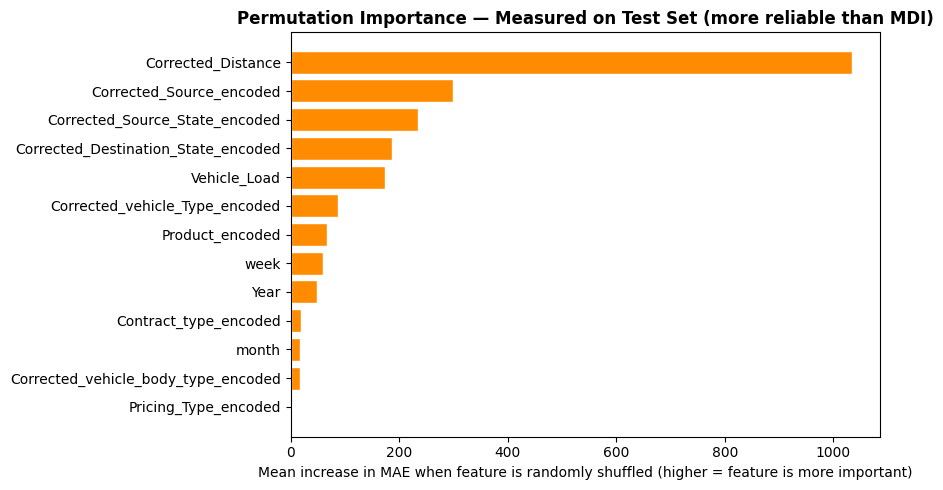

In [15]:
perm = permutation_importance(
    gb_tuned, X_test, y_test,
    n_repeats=5,                              # shuffle each feature 5 times, take the average
    random_state=42,
    scoring='neg_mean_absolute_error'         # measure impact on MAE
)

perm_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Perm Score': perm.importances_mean       # mean MAE increase when feature is shuffled
}).sort_values('Perm Score', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(perm_df['Feature'], perm_df['Perm Score'], color='darkorange', edgecolor='white')
plt.xlabel('Mean increase in MAE when feature is randomly shuffled (higher = feature is more important)')
plt.title('Permutation Importance — Measured on Test Set (more reliable than MDI)', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Testing Optimized GB Model (High-Cost Classification)

Regression metrics (R², RMSE, MAE) measure average prediction accuracy across all
shipments. But freight businesses care especially about **high-cost shipments** —
mislabelling an expensive route as "normal" has major budget consequences.

We derive a binary label: shipments in the top 20% of costs (above the 80th percentile
of training costs) are labelled **"High-cost" (1)**, everything else is **"Normal" (0)**.

This label is a fixed property of the **actual** costs — it does not depend on the model.
We then check how accurately each model identifies these high-cost shipments.

In [16]:
HIGH_COST_PCT       = 0.80   # top 20% of training costs = "High-cost" class
high_cost_threshold = np.quantile(y_train, HIGH_COST_PCT)
print(f"High-cost threshold (80th percentile of training Cost): ₹{high_cost_threshold:,.0f}")

y_test_bin       = (y_test.values >= high_cost_threshold).astype(int)   # ground truth from actual cost
gb_pred_test     = gb_tuned.predict(X_test)                             # tuned model predictions
y_pred_bin_tuned = (gb_pred_test >= high_cost_threshold).astype(int)    # predicted class from tuned model

# Normalised score for ROC-AUC (needs a continuous score, not just 0/1)
score_tuned = gb_pred_test - high_cost_threshold
score_tuned = (score_tuned - score_tuned.min()) / (score_tuned.max() - score_tuned.min())

print("\nOptimised GB — High-Cost Detection")
print(f"Precision : {precision_score(y_test_bin, y_pred_bin_tuned, zero_division=0):.4f}  (of all predicted high-cost, how many actually are?)")
print(f"Recall    : {recall_score(y_test_bin, y_pred_bin_tuned,    zero_division=0):.4f}  (of all actual high-cost, how many did we catch?)")
print(f"F1 Score  : {f1_score(y_test_bin, y_pred_bin_tuned,        zero_division=0):.4f}  (harmonic mean of precision and recall)")
print(f"ROC-AUC   : {roc_auc_score(y_test_bin, score_tuned):.4f}  (1.0 = perfect separation; 0.5 = random)")

High-cost threshold (80th percentile of training Cost): ₹3,730



Optimised GB — High-Cost Detection
Precision : 0.9190  (of all predicted high-cost, how many actually are?)
Recall    : 0.8841  (of all actual high-cost, how many did we catch?)
F1 Score  : 0.9012  (harmonic mean of precision and recall)
ROC-AUC   : 0.9897  (1.0 = perfect separation; 0.5 = random)


## 11. Testing Base GB Model

In [17]:
# Same threshold and ground-truth labels — only the model predictions change
y_pred_bin_base = (gb_base_preds >= high_cost_threshold).astype(int)

score_base = gb_base_preds - high_cost_threshold
score_base = (score_base - score_base.min()) / (score_base.max() - score_base.min())

print("Base GB — High-Cost Detection")
print(f"Precision : {precision_score(y_test_bin, y_pred_bin_base, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test_bin, y_pred_bin_base,    zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_test_bin, y_pred_bin_base,        zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_bin, score_base):.4f}")

Base GB — High-Cost Detection
Precision : 0.8327
Recall    : 0.7083
F1 Score  : 0.7655
ROC-AUC   : 0.9498


## 12. Comparison — Base vs Optimized GB

> **Note on reading this chart:** Higher scores are better for all four metrics.
> Recall is often the most important metric for high-cost freight detection — missing
> an expensive shipment (low recall) is more costly than a false alarm (low precision).

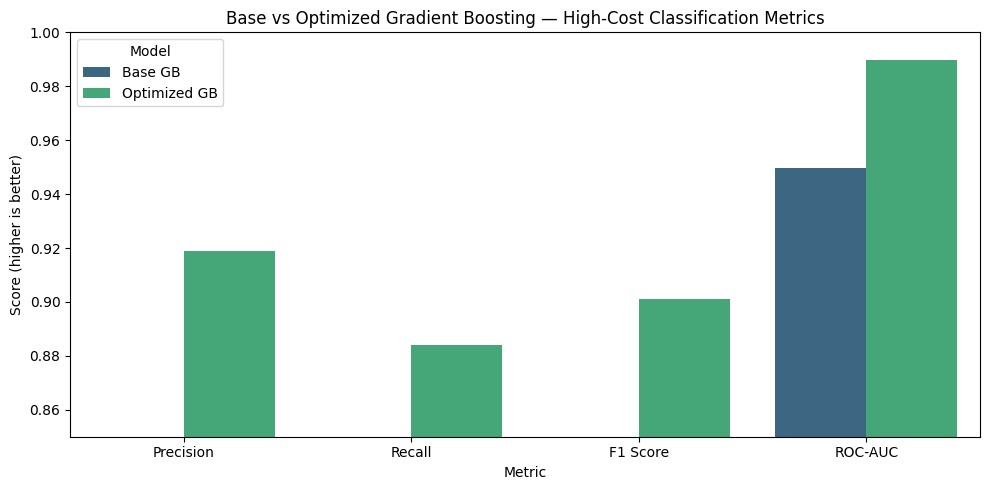

In [18]:
metrics = ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']

base_scores = [
    precision_score(y_test_bin, y_pred_bin_base, zero_division=0),
    recall_score(y_test_bin, y_pred_bin_base, zero_division=0),
    f1_score(y_test_bin, y_pred_bin_base, zero_division=0),
    roc_auc_score(y_test_bin, score_base)
]
opt_scores = [
    precision_score(y_test_bin, y_pred_bin_tuned, zero_division=0),
    recall_score(y_test_bin, y_pred_bin_tuned, zero_division=0),
    f1_score(y_test_bin, y_pred_bin_tuned, zero_division=0),
    roc_auc_score(y_test_bin, score_tuned)
]

df_plot = pd.DataFrame({
    'Metric': metrics * 2,
    'Score':  base_scores + opt_scores,
    'Model':  ['Base GB'] * 4 + ['Optimized GB'] * 4
})

plt.figure(figsize=(10, 5))
sns.barplot(data=df_plot, x='Metric', y='Score', hue='Model', palette='viridis')
plt.title('Base vs Optimized Gradient Boosting — High-Cost Classification Metrics')
plt.ylabel('Score (higher is better)')
plt.ylim(0.85, 1.0)     # zoom in to see differences — all scores are high
plt.legend(title='Model')
plt.tight_layout()
plt.show()

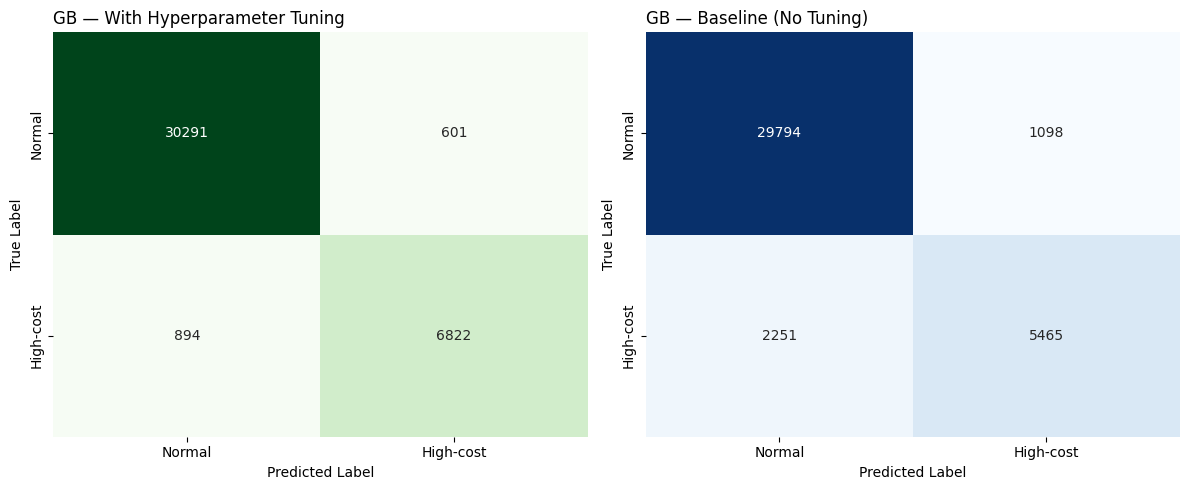

In [19]:
# Confusion matrices — rows = actual class, columns = predicted class
# True Positive  (bottom-right): correctly identified High-cost shipments
# False Negative (bottom-left):  missed High-cost shipments — the costly error
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

cm_tuned = confusion_matrix(y_test_bin, y_pred_bin_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', ax=ax[0], cbar=False)
ax[0].set_xticklabels(['Normal', 'High-cost'])
ax[0].set_yticklabels(['Normal', 'High-cost'])
ax[0].set_title('GB — With Hyperparameter Tuning', loc='left')
ax[0].set_xlabel('Predicted Label'); ax[0].set_ylabel('True Label')

cm_base = confusion_matrix(y_test_bin, y_pred_bin_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=ax[1], cbar=False)
ax[1].set_xticklabels(['Normal', 'High-cost'])
ax[1].set_yticklabels(['Normal', 'High-cost'])
ax[1].set_title('GB — Baseline (No Tuning)', loc='left')
ax[1].set_xlabel('Predicted Label'); ax[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### Understanding the Confusion Matrix Results

For Gradient Boosting the usual pattern is the **opposite** of an overfit-prone model.
The baseline uses only 100 shallow trees at the default learning rate, so it tends to
**underfit slightly** and leave some signal on the table. Tuning then adds boosting
stages and adjusts the learning rate / subsample, so the optimized model typically
catches a few more high-cost shipments.

If the two confusion matrices look almost identical, that simply means the defaults were
already close to optimal for this dataset — tuning a gradient booster has diminishing
returns once the number of stages, learning rate and subsample are balanced.

**Why classification can disagree with regression metrics.** Precision/Recall here come
from thresholding a *continuous* cost prediction at the 80th percentile. A model can be
better "on average" (higher R², lower RMSE) yet flip a handful of borderline shipments
around the threshold, nudging precision or recall slightly. That is why the final model
choice in Section 13 is driven by **R², RMSE and the train–test gap**, not by the
classification view alone.

## 13. Final Performance Analysis

In [20]:
gb_tuned_preds     = gb_tuned.predict(X_test)   # final predictions on the held-out test set
gb_tuned_val_preds = gb_tuned.predict(X_val)

tuned_r2     = r2_score(y_test, gb_tuned_preds)
tuned_adj_r2 = 1 - (1 - tuned_r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
tuned_rmse   = mean_squared_error(y_test, gb_tuned_preds) ** 0.5
tuned_mae    = mean_absolute_error(y_test, gb_tuned_preds)
tuned_val_r2 = r2_score(y_val, gb_tuned_val_preds)
base_mape    = mean_absolute_percentage_error(y_test, gb_base_preds)  * 100
tuned_mape   = mean_absolute_percentage_error(y_test, gb_tuned_preds) * 100

final_metrics = pd.DataFrame({
    'Model':   ['Gradient Boosting (Baseline)', 'Gradient Boosting (Tuned)'],
    'Val R²':  [round(base_val_r2, 4), round(tuned_val_r2, 4)],
    'Test R²': [round(base_r2, 4),     round(tuned_r2, 4)],
    'Adj R²':  [round(base_adj_r2, 4), round(tuned_adj_r2, 4)],
    'RMSE':    [round(base_rmse, 2),   round(tuned_rmse, 2)],
    'MAE':     [round(base_mae, 2),    round(tuned_mae, 2)],
    'MAPE %':  [round(base_mape, 2),   round(tuned_mape, 2)]
})
print(final_metrics.to_string(index=False))

print(f"\n{'✅' if tuned_r2 >= 0.95 else '⚠️'} Tuned GB test R² = {tuned_r2:.4f}  (target ≥ 0.95)")

                       Model  Val R²  Test R²  Adj R²   RMSE    MAE  MAPE %
Gradient Boosting (Baseline)  0.8026   0.8020  0.8019 623.33 409.57   29.53
   Gradient Boosting (Tuned)  0.9586   0.9581  0.9580 286.90 172.16   13.14

✅ Tuned GB test R² = 0.9581  (target ≥ 0.95)


In [21]:
# Select the final model using VALIDATION R² (the test set stays untouched for the final figure)
if tuned_val_r2 >= base_val_r2:
    best_model = gb_tuned
    best_label = "Tuned GB"
    best_r2    = tuned_r2
    print("✅ Tuned model wins on validation — selected as final model.")
else:
    best_model = gb_base
    best_label = "Baseline GB"
    best_r2    = base_r2
    print("ℹ️  Baseline model wins on validation — selected as final model.")

print(f"   Final model test R²: {best_r2:.4f}")

✅ Tuned model wins on validation — selected as final model.
   Final model test R²: 0.9581


In [22]:
# Improvement delta — positive = tuned is better, negative = baseline is better
delta_r2   = tuned_r2   - base_r2
delta_rmse = base_rmse  - tuned_rmse    # positive means tuned has lower (better) RMSE
delta_mae  = base_mae   - tuned_mae

print("Improvement (Baseline → Tuned):")
print(f"  R²  : {delta_r2:+.4f}  {'↑ improved' if delta_r2 > 0 else '↓ baseline was stronger'}")
print(f"  RMSE: {delta_rmse:+.2f} ₹  {'↑ improved' if delta_rmse > 0 else '↓ baseline was stronger'}")
print(f"  MAE : {delta_mae:+.2f} ₹  {'↑ improved' if delta_mae > 0 else '↓ baseline was stronger'}")

Improvement (Baseline → Tuned):
  R²  : +0.1560  ↑ improved
  RMSE: +336.43 ₹  ↑ improved
  MAE : +237.40 ₹  ↑ improved


In [23]:
# Train / Validation / Test R² for both models — generalisation check
tuned_train_r2 = r2_score(y_train, gb_tuned.predict(X_train))
tuned_gap      = tuned_train_r2 - tuned_r2

print(f"{'Model':16s}  Train R²   Val R²    Test R²    Gap")
print(f"{'Baseline GB':16s}  {base_train_r2:.4f}    {base_val_r2:.4f}   {base_r2:.4f}    {base_gap:.4f}")
print(f"{'Tuned GB':16s}  {tuned_train_r2:.4f}    {tuned_val_r2:.4f}   {tuned_r2:.4f}    {tuned_gap:.4f}")

Model             Train R²   Val R²    Test R²    Gap
Baseline GB       0.7984    0.8026   0.8020    -0.0036
Tuned GB          0.9715    0.9586   0.9581    0.0135


## 14. SHAP Analysis — Explainable AI (XAI)

SHAP (SHapley Additive exPlanations) explains **why** the model made each specific
prediction. It is based on Shapley values from game theory: for each shipment, how
much did each feature contribute to moving the prediction above or below the average cost?

We produce three SHAP visualisations:
- **Bar plot:** Global importance — which features matter most on average
- **Summary (beeswarm) plot:** Direction — does high distance push cost up or down?
- **Waterfall plot:** Individual explanation — why did the model predict ₹X for one specific shipment?

In [24]:
# Use the best model (baseline or tuned, selected above)
# TreeExplainer works natively with GradientBoostingRegressor — no background dataset needed
explainer = shap.TreeExplainer(best_model, feature_perturbation='tree_path_dependent')

# Sample 2000 test rows — exact Shapley computation is slow on the full test set
X_test_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values   = explainer(X_test_sample)   # returns an Explanation object

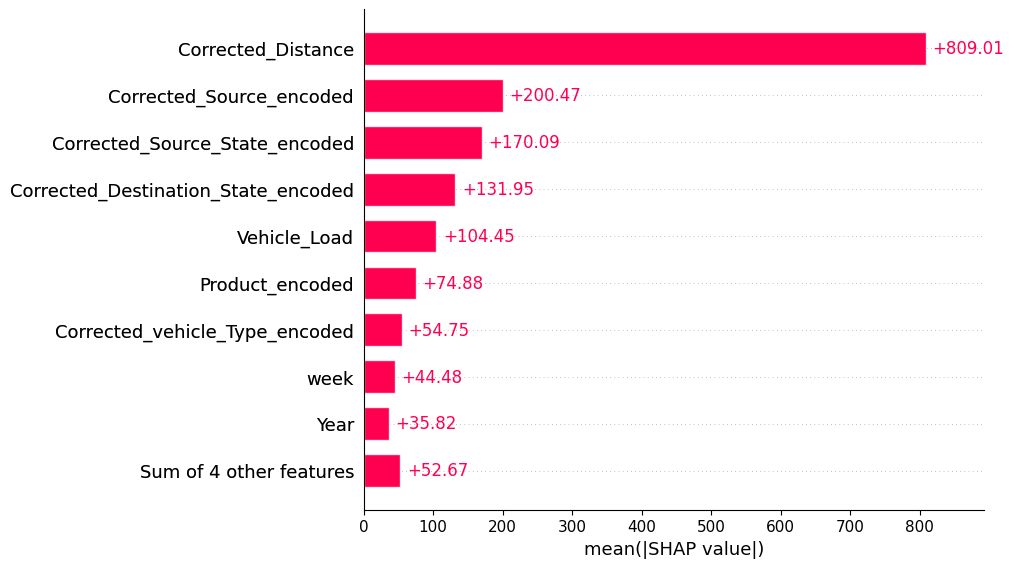

In [25]:
# SHAP Bar Plot — global mean absolute SHAP value per feature
# Shows which features matter most across all test shipments
shap.plots.bar(shap_values)

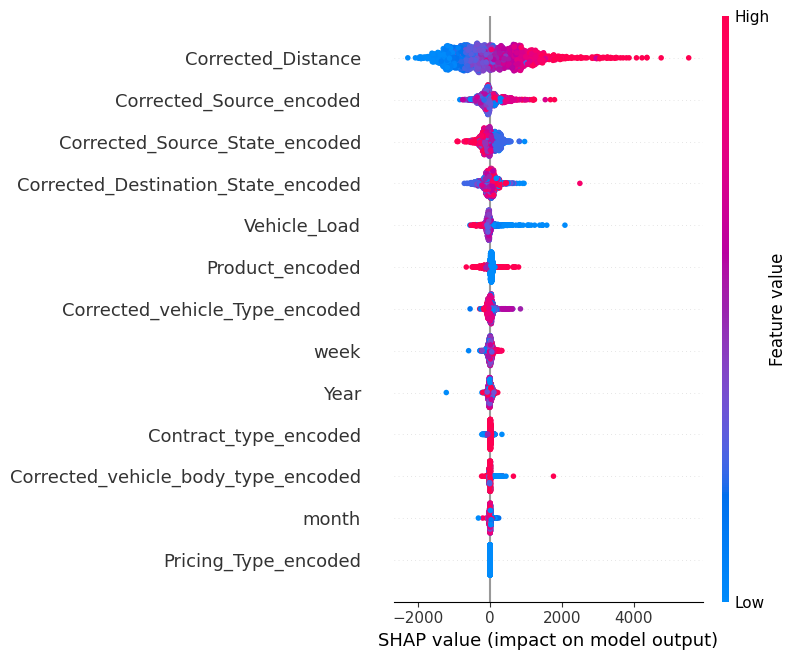

In [26]:
# SHAP Summary (Beeswarm) Plot — each dot is one shipment
# X-axis: SHAP value (positive = pushes predicted cost UP, negative = pushes DOWN)
# Colour:  Red = high raw feature value, Blue = low feature value
shap.summary_plot(shap_values, X_test_sample)

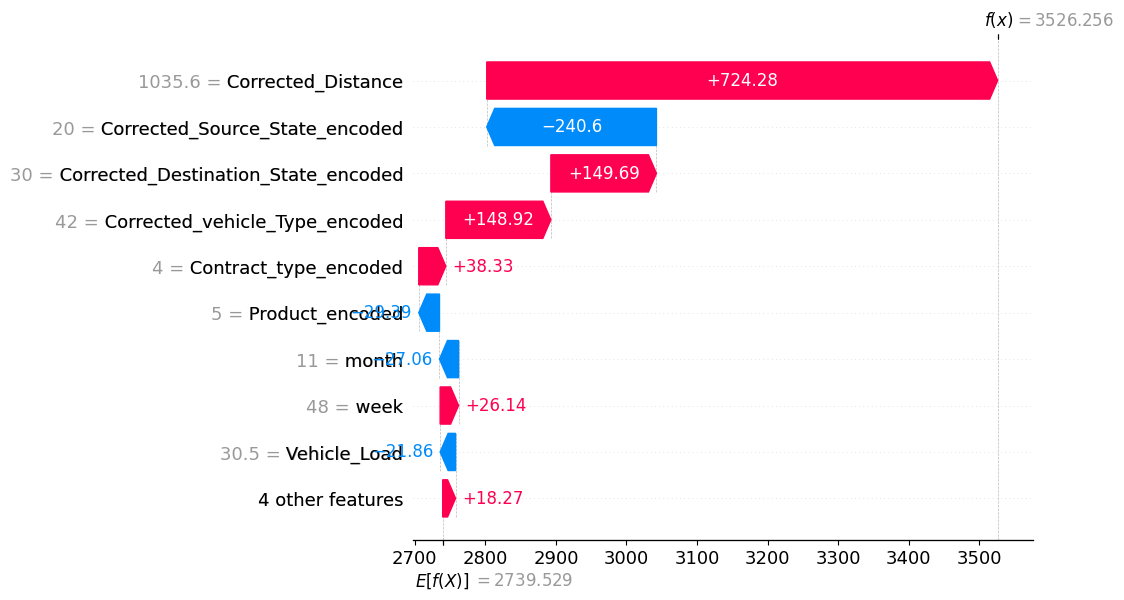

In [27]:
# SHAP Waterfall Plot — explains ONE individual prediction step by step
# Shows how each feature moved the prediction from the average (baseline) to the final value
# Change index_to_explain to inspect any specific shipment
index_to_explain = 0
shap.plots.waterfall(shap_values[index_to_explain])

## 15. Forecast — April, Week 1 & Week 2

Forecasts one route-level cost per unique route/contract/vehicle combination seen in
the historical data, for the first two ISO weeks of April. Uses the **best selected model**.

`TARGET_YEAR` defaults to one year past the latest year in the data. Note that `Year`
is being extrapolated beyond what the model was trained on, so treat that part of the
forecast as directional rather than exact.

In [28]:
TARGET_YEAR  = int(df['Year'].max()) + 1
TARGET_MONTH = 4   # April

def get_weeks_touching_month(year, month):
    # Returns all ISO week numbers that contain at least one day in the given month
    first_day  = datetime(year, month, 1)
    next_month = month + 1 if month < 12 else 1
    next_year  = year if month < 12 else year + 1
    last_day   = datetime(next_year, next_month, 1) - timedelta(days=1)
    weeks, current = [], first_day
    while current <= last_day:
        iso_week = current.isocalendar()[1]
        if iso_week not in weeks:
            weeks.append(iso_week)
        current += timedelta(days=1)
    return weeks

april_weeks  = get_weeks_touching_month(TARGET_YEAR, TARGET_MONTH)
target_weeks = april_weeks[:2]   # Week 1 and Week 2 of April
print(f"Forecasting April {TARGET_YEAR}, ISO weeks: {target_weeks}")

Forecasting April 2026, ISO weeks: [14, 15]


In [29]:
group_cols = [
    'Route_name', 'Contract_type', 'Corrected_Source', 'Corrected_Source_State',
    'Pricing_Type', 'Product', 'Corrected_vehicle_Type',
    'Corrected_vehicle_body_type', 'Corrected_Destination_State'
]

available_group_cols = [c for c in group_cols if c in df.columns]  # skip if column is absent

route_profile = df.groupby(available_group_cols, as_index=False).agg(
    Corrected_Distance=('Corrected_Distance', 'mean'),   # average distance per route
    Vehicle_Load=('Vehicle_Load', 'median')              # typical load for the route
)

weeks_df       = pd.DataFrame({'week': target_weeks, 'month': TARGET_MONTH, 'Year': TARGET_YEAR})
forecast_input = route_profile.merge(weeks_df, how='cross')    # one row per route per week
print(forecast_input.shape)

(132668, 14)


In [30]:
# Apply the same encoding used during training (stored in encoding_mapping)
for col in categorical_columns:
    if col in forecast_input.columns:
        forecast_input[f'{col}_encoded'] = forecast_input[col].map(encoding_mapping[col])

# Fill any feature column not present in forecast_input with the training median
for col in feature_cols:
    if col not in forecast_input.columns:
        forecast_input[col] = X_train[col].median()

X_future = forecast_input[feature_cols]
forecast_input['Predicted_Cost'] = best_model.predict(X_future)   # use the best model

week_label_map               = {target_weeks[0]: 'Week 1', target_weeks[1]: 'Week 2'}
forecast_input['Week_Label'] = forecast_input['week'].map(week_label_map)

display_cols = available_group_cols + ['Year', 'month', 'week', 'Week_Label', 'Corrected_Distance', 'Predicted_Cost']
forecast_df  = forecast_input[display_cols].sort_values(['week', display_cols[0]]).reset_index(drop=True)
forecast_df.head(10)

,Route_name,Contract_type,Corrected_Source,Corrected_Source_State,Pricing_Type,Product,Corrected_vehicle_Type,Corrected_vehicle_body_type,Corrected_Destination_State,Year,month,week,Week_Label,Corrected_Distance,Predicted_Cost
0,AGRA - GAYA,SHORT,agra,uttar pradesh,Rate/MT,Edible Oil,TAURUS 25 MT 12 TYRE,FULL PUNJAB BODY,Bihar,2026,4,14,Week 1,837.36,2951.182073
1,AGRA - KANPUR,DAILY,agra,uttar pradesh,Rate/MT,Edible Oil,TAURUS 18-19 MT 10 TYRE,FULL PUNJAB BODY,Uttar Pradesh,2026,4,14,Week 1,279.87,1872.812469
2,AGRA - KOLKATA,SHORT,agra,uttar pradesh,Rate/MT,Edible Oil,TAURUS 30 MT 14 TYRE,FULL PUNJAB BODY,West Bengal,2026,4,14,Week 1,1270.07,3302.145415
3,AGRA - PATNA,SHORT,agra,uttar pradesh,Rate/MT,Edible Oil,TAURUS 25 MT 12 TYRE,FULL PUNJAB BODY,Bihar,2026,4,14,Week 1,855.95,3049.062703
4,AGRA - PATNA,SHORT,agra,uttar pradesh,Rate/MT,Edible Oil,TAURUS 30 MT 14 TYRE,FULL PUNJAB BODY,Bihar,2026,4,14,Week 1,855.95,2837.571627
5,AHMEDABAD - VIDISHA,DAILY,ahmedabad,gujarat,Rate/MT,Nuggets,EICHER 7-9 MT 19 FT,FULL PUNJAB BODY,Madhya Pradesh,2026,4,14,Week 1,667.31,3496.143396
6,AKOLA - AKOLA,LONG,akola,maharashtra,Rate/MT,Pulses,TAURUS 30 MT 14 TYRE,FULL PUNJAB BODY,Maharashtra,2026,4,14,Week 1,15.00,355.644141
7,AKOLA - AKOLA,MONTHLY,akola,maharashtra,Rate/MT,Pulses,TAURUS 30 MT 14 TYRE,FULL PUNJAB BODY,Maharashtra,2026,4,14,Week 1,15.00,385.212217
8,AKOLA - AKOLA,SHORT,akola,maharashtra,Rate/MT,Pulses,TAURUS 30 MT 14 TYRE,FULL PUNJAB BODY,Maharashtra,2026,4,14,Week 1,15.00,562.140308
9,AKOLA - CHILBILA,SHORT,akola,maharashtra,Rate/MT,Edible Oil,TAURUS 30 MT 14 TYRE,FULL PUNJAB BODY,Uttar Pradesh,2026,4,14,Week 1,980.08,3634.619354


In [31]:
forecast_df.to_csv('april_week1_week2_forecast_gradient_boosting.csv', index=False)
print("Saved: april_week1_week2_forecast_gradient_boosting.csv")

Saved: april_week1_week2_forecast_gradient_boosting.csv


## 16. SSP vs Actual — Dashboard Visualizations

In [32]:
# Historical predictions on the full dataset — used for all dashboard charts below
df['Predicted_Cost_hist'] = best_model.predict(df[feature_cols])

month_names = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

### 16.1 SSP vs Actual Contract Price Trend (Monthly)

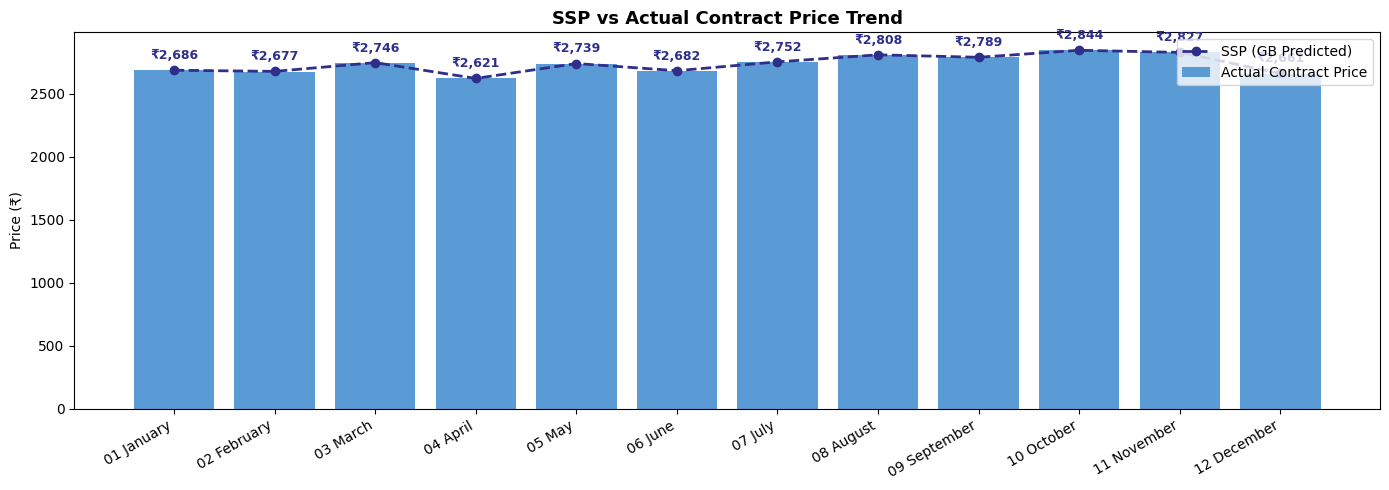

In [33]:
monthly_trend = (
    df.groupby('month', as_index=False)
      .agg(Actual=('Cost', 'mean'), SSP=('Predicted_Cost_hist', 'mean'))
      .sort_values('month')
)
monthly_trend['Month_Label'] = monthly_trend['month'].apply(lambda m: f"{m:02d} {month_names[m-1]}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_trend['Month_Label'], monthly_trend['Actual'],   color='#5B9BD5', label='Actual Contract Price')
ax.plot(monthly_trend['Month_Label'], monthly_trend['SSP'],     color='#2E2E8B', linestyle='--',
        marker='o', linewidth=2, label='SSP (GB Predicted)')
for x, y in zip(monthly_trend['Month_Label'], monthly_trend['SSP']):
    ax.annotate(f'₹{y:,.0f}', (x, y), textcoords="offset points",
                xytext=(0, 8), ha='center', fontsize=9, color='#2E2E8B', fontweight='bold')
ax.set_title('SSP vs Actual Contract Price Trend', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (₹)')
ax.legend(loc='upper right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 16.2 Predicted Price — Forecast Period

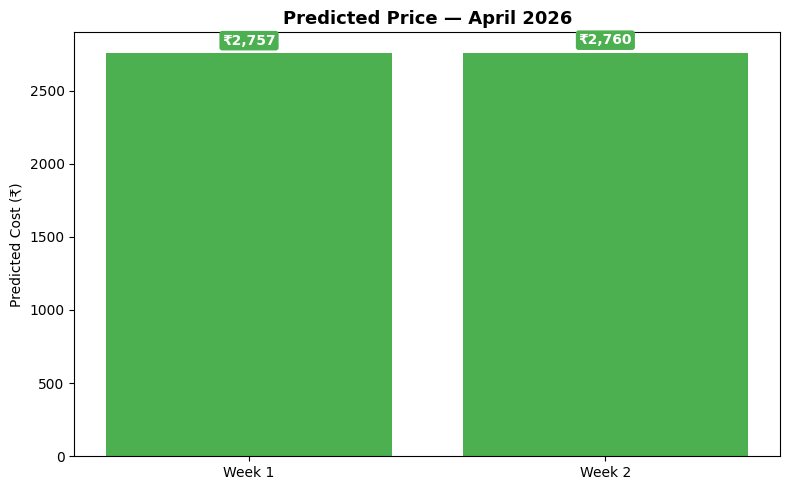

In [34]:
predicted_price = (
    forecast_df.groupby('Week_Label', as_index=False)['Predicted_Cost']
    .mean().sort_values('Week_Label')
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(predicted_price['Week_Label'], predicted_price['Predicted_Cost'], color='#4CAF50')
for rect, val in zip(bars, predicted_price['Predicted_Cost']):
    ax.annotate(f'₹{val:,.0f}', (rect.get_x() + rect.get_width()/2, val),
                textcoords="offset points", xytext=(0, 6), ha='center',
                fontsize=10, color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='#4CAF50', ec='none'))
ax.set_title(f'Predicted Price — April {TARGET_YEAR}', fontsize=13, fontweight='bold')
ax.set_ylabel('Predicted Cost (₹)')
plt.tight_layout()
plt.show()

### 16.3 SSP – Actual vs Predicted vs Weight (Monthly Table)

In [35]:
monthly_table = (
    df.groupby('month')
      .apply(lambda g: pd.Series({
          'Price':        np.average(g['Cost'],               weights=g['Vehicle_Load']),
          'SSP':          np.average(g['Predicted_Cost_hist'], weights=g['Vehicle_Load']),
          'Weight (LMT)': g['Vehicle_Load'].sum()
      }))
      .reset_index().sort_values('month')
)
monthly_table['Month'] = monthly_table['month'].apply(lambda m: month_names[int(m)-1])
monthly_table = monthly_table[['Month', 'Price', 'SSP', 'Weight (LMT)']]

(
    monthly_table.style
    .set_caption('SSP – Actual vs Predicted Value vs Weight')
    .format({'Price': '₹{:,.2f}', 'SSP': '₹{:,.2f}', 'Weight (LMT)': '{:,.1f}'})
    .background_gradient(subset=['Price', 'SSP'], cmap='Blues')
)

,Month,Price,SSP,Weight (LMT)
0,January,"₹2,813.23","₹2,812.03","791,074.5"
1,February,"₹2,804.36","₹2,806.10","622,968.0"
2,March,"₹2,852.50","₹2,852.23","614,705.0"
3,April,"₹2,759.09","₹2,758.38","766,839.0"
4,May,"₹2,852.58","₹2,855.01","844,719.0"
5,June,"₹2,775.09","₹2,773.09","754,763.5"
6,July,"₹2,851.30","₹2,848.71","861,452.0"
7,August,"₹2,903.11","₹2,902.39","828,478.0"
8,September,"₹2,880.69","₹2,881.53","842,117.0"
9,October,"₹2,964.63","₹2,966.09","884,428.0"


### 16.4 SSP vs Spent Trend & Savings

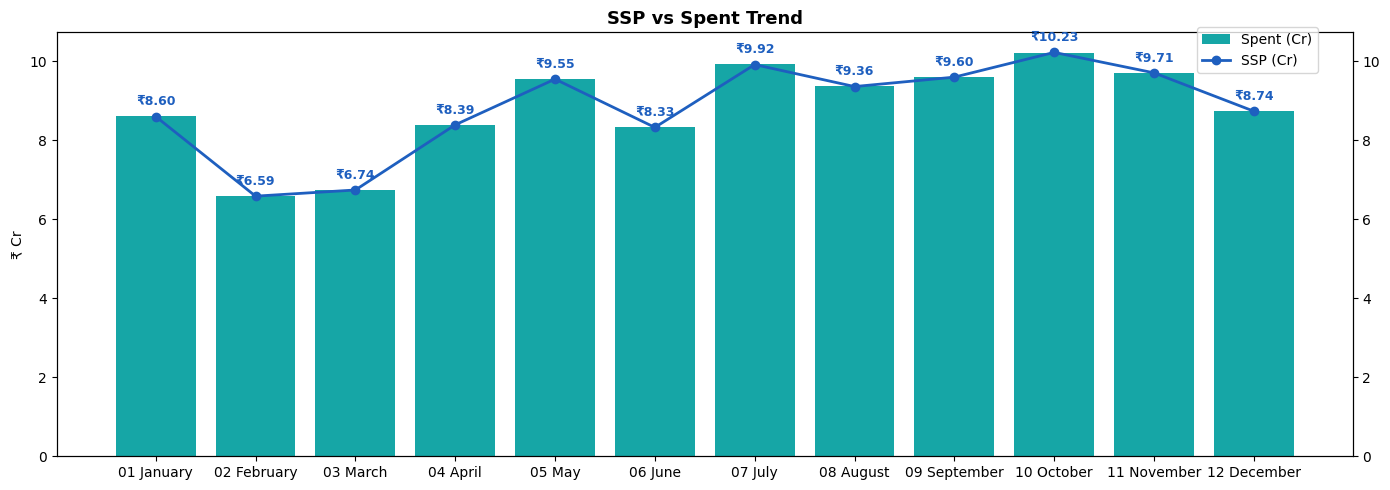

,Month,SSP (Cr),Spent (Cr),Savings (Cr)
0,01 January,₹8.60,₹8.61,₹-0.00
1,02 February,₹6.59,₹6.58,₹0.00
2,03 March,₹6.74,₹6.74,₹-0.00
3,04 April,₹8.39,₹8.39,₹-0.00
4,05 May,₹9.55,₹9.54,₹0.01
5,06 June,₹8.33,₹8.33,₹-0.00
6,07 July,₹9.92,₹9.93,₹-0.01
7,08 August,₹9.36,₹9.36,₹-0.00
8,09 September,₹9.60,₹9.60,₹-0.00
9,10 October,₹10.23,₹10.22,₹0.00


In [36]:
spend_trend = (
    df.groupby('month')
      .agg(Spent=('Cost', 'sum'), SSP=('Predicted_Cost_hist', 'sum'))
      .reset_index().sort_values('month')
)
spend_trend['Month']      = spend_trend['month'].apply(lambda m: f"{m:02d} {month_names[m-1]}")
spend_trend['Spent_Cr']   = spend_trend['Spent'] / 1e7     # convert to crores
spend_trend['SSP_Cr']     = spend_trend['SSP']   / 1e7
spend_trend['Savings_Cr'] = spend_trend['SSP_Cr'] - spend_trend['Spent_Cr']

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(spend_trend['Month'], spend_trend['Spent_Cr'], color='#16A6A6', label='Spent (Cr)')
ax1.set_ylabel('₹ Cr')
ax2 = ax1.twinx()
ax2.plot(spend_trend['Month'], spend_trend['SSP_Cr'],
         color='#1E5FBF', marker='o', linewidth=2, label='SSP (Cr)')
ax2.set_ylim(ax1.get_ylim())
for x, y in zip(spend_trend['Month'], spend_trend['SSP_Cr']):
    ax2.annotate(f'₹{y:,.2f}', (x, y), textcoords="offset points",
                 xytext=(0, 8), ha='center', fontsize=9, color='#1E5FBF', fontweight='bold')
ax1.set_title('SSP vs Spent Trend', fontsize=13, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

savings_table = spend_trend[['Month', 'SSP_Cr', 'Spent_Cr', 'Savings_Cr']].copy()
savings_table.columns = ['Month', 'SSP (Cr)', 'Spent (Cr)', 'Savings (Cr)']
(
    savings_table.style
    .set_caption('SSP vs Spent vs Savings')
    .format({'SSP (Cr)':'₹{:,.2f}','Spent (Cr)':'₹{:,.2f}','Savings (Cr)':'₹{:,.2f}'})
    .background_gradient(subset=['Savings (Cr)'], cmap='Greens')
)

### 16.5 Predicted — Weighted Average Price by Route

In [37]:
top_source = df['Corrected_Source'].value_counts().idxmax()   # busiest source location

route_price = (
    df[df['Corrected_Source'] == top_source]
    .groupby(['Corrected_Source', 'Corrected_Destination_State',
              'Contract_type', 'Corrected_vehicle_body_type', 'Corrected_vehicle_Type'])
    .apply(lambda g: pd.Series({
        'SSP':    np.average(g['Predicted_Cost_hist'], weights=g['Vehicle_Load']),
        'Actual': np.average(g['Cost'],               weights=g['Vehicle_Load'])
    }))
    .reset_index()
    .rename(columns={
        'Corrected_Source': 'From Location', 'Corrected_Destination_State': 'To State',
        'Contract_type': 'Contract Type', 'Corrected_vehicle_body_type': 'Body Type',
        'Corrected_vehicle_Type': 'Vehicle Type'
    })
    .sort_values('Actual', ascending=False).head(12).reset_index(drop=True)
)

grand_total = pd.DataFrame([{
    'From Location':'','To State':'','Contract Type':'','Body Type':'',
    'Vehicle Type':'Grand total',
    'SSP': route_price['SSP'].mean(), 'Actual': route_price['Actual'].mean()
}])
route_price_display = pd.concat([route_price, grand_total], ignore_index=True)

(
    route_price_display.style
    .set_caption(f'Predicted — Weighted Average Price (From: {top_source.upper()})')
    .format({'SSP':'₹{:,.2f}','Actual':'₹{:,.2f}'})
    .background_gradient(subset=['SSP'],    cmap='Blues')
    .background_gradient(subset=['Actual'], cmap='Oranges')
)

,From Location,To State,Contract Type,Body Type,Vehicle Type,SSP,Actual
0,haldia,Jammu & Kashmir,DAILY,FULL PUNJAB BODY,TAURUS 21-22 MT 12 TYRE,"₹7,595.00","₹7,389.00"
1,haldia,Tripura,SHORT,FULL PUNJAB BODY,TAURUS 21-22 MT 12 TYRE,"₹6,472.87","₹6,975.00"
2,haldia,Assam,SHORT,CONTAINER BODY,SINGLE AXLE CONTAINER 7-9 MT 32 FT,"₹6,688.54","₹6,847.24"
3,haldia,Jammu & Kashmir,MONTHLY,CONTAINER BODY,MULTI AXLE CONTAINER 25 MT 32 FT,"₹6,835.17","₹6,817.95"
4,haldia,Jammu & Kashmir,SHORT,FULL PUNJAB BODY,TAURUS 21-22 MT 12 TYRE,"₹6,171.46","₹6,209.07"
5,haldia,Bihar,SHORT,CONTAINER BODY,SINGLE AXLE CONTAINER 7-9 MT 32 FT,"₹5,348.81","₹5,737.50"
6,haldia,Jammu & Kashmir,LONG,CONTAINER BODY,MULTI AXLE CONTAINER 25 MT 32 FT,"₹5,635.33","₹5,587.33"
7,haldia,Assam,SHORT,CONTAINER BODY,REFER CONTAINER 18 MT 28 FT,"₹5,447.33","₹5,230.00"
8,haldia,Assam,SHORT,CONTAINER BODY,REFER CONTAINER 15 MT 28 FT,"₹5,428.68","₹5,230.00"
9,haldia,Assam,SHORT,FULL PUNJAB BODY,MULTI AXLE CONTAINER 22 MT 32 FT,"₹4,222.99","₹4,825.00"


### 16.6 LPP / SSP / LOI Price / QBR — by Contract Type

In [38]:
# LPP = min Cost, LOI Price = mean Cost, QBR = max Cost, SSP = mean Predicted
# (proxies — replace with real columns if available)
contract_summary = (
    df.groupby('Contract_type')
      .agg(LPP=('Cost','min'), SSP=('Predicted_Cost_hist','mean'),
           LOI_Price=('Cost','mean'), QBR=('Cost','max'))
      .reset_index().rename(columns={'Contract_type':'Contract Type','LOI_Price':'LOI Price'})
)
grand_total_row = pd.DataFrame([{
    'Contract Type':'Grand total',
    'LPP':df['Cost'].min(), 'SSP':df['Predicted_Cost_hist'].mean(),
    'LOI Price':df['Cost'].mean(), 'QBR':df['Cost'].max()
}])
contract_summary_display = pd.concat([contract_summary, grand_total_row], ignore_index=True)

(
    contract_summary_display.style
    .set_caption('LPP vs SSP vs LOI Price vs QBR — by Contract Type')
    .format({'LPP':'₹{:,.0f}','SSP':'₹{:,.0f}','LOI Price':'₹{:,.0f}','QBR':'₹{:,.0f}'})
    .background_gradient(subset=['LPP'],       cmap='Purples')
    .background_gradient(subset=['SSP'],       cmap='Greens')
    .background_gradient(subset=['LOI Price'], cmap='Oranges')
    .background_gradient(subset=['QBR'],       cmap='Reds')
)

,Contract Type,LPP,SSP,LOI Price,QBR
0,DAILY,₹27,"₹2,789","₹2,793","₹17,591"
1,LONG,₹15,"₹2,424","₹2,424","₹20,970"
2,MONTHLY,₹25,"₹2,315","₹2,314","₹18,460"
3,SHORT,₹5,"₹2,820","₹2,820","₹17,899"
4,SPOT,₹37,"₹2,445","₹2,449","₹15,710"
5,Grand total,₹5,"₹2,739","₹2,740","₹20,970"


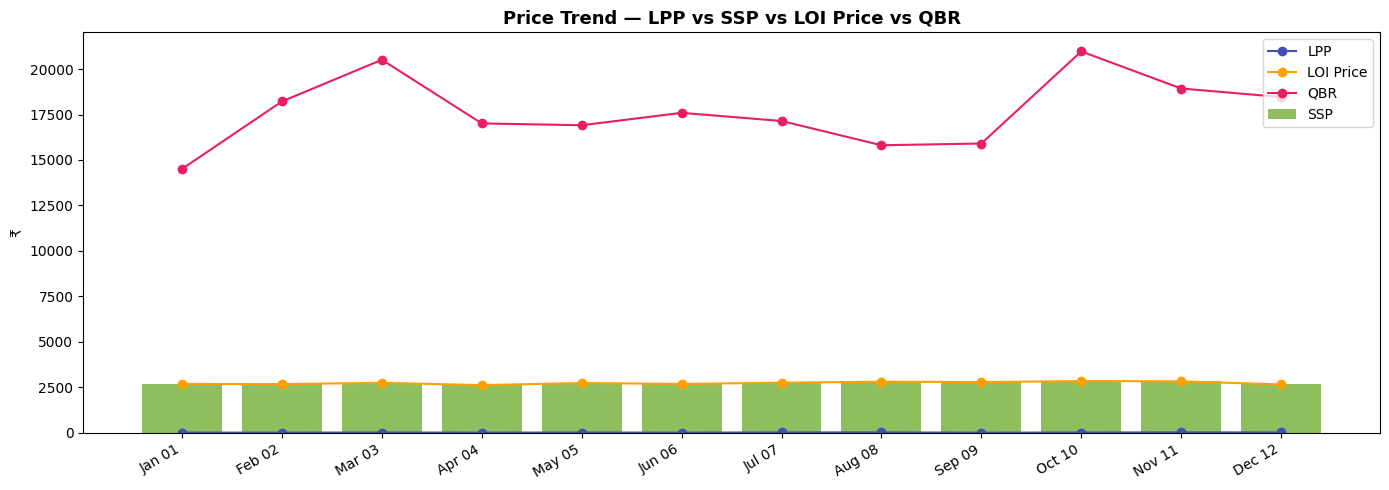

In [39]:
trend_summary = (
    df.groupby('month')
      .agg(LPP=('Cost','min'), SSP=('Predicted_Cost_hist','mean'),
           LOI_Price=('Cost','mean'), QBR=('Cost','max'))
      .reset_index().sort_values('month')
)
trend_summary['Month'] = trend_summary['month'].apply(lambda m: month_names[m-1][:3] + f" {m:02d}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(trend_summary['Month'],  trend_summary['SSP'],       color='#7CB342', label='SSP',       alpha=0.85)
ax.plot(trend_summary['Month'], trend_summary['LPP'],       color='#3F51B5', marker='o', label='LPP')
ax.plot(trend_summary['Month'], trend_summary['LOI_Price'], color='#FFA000', marker='o', label='LOI Price')
ax.plot(trend_summary['Month'], trend_summary['QBR'],       color='#E91E63', marker='o', label='QBR')
ax.set_title('Price Trend — LPP vs SSP vs LOI Price vs QBR', fontsize=13, fontweight='bold')
ax.set_ylabel('₹')
ax.legend(loc='upper right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()